# PROYECTO FINAL: LIMPIEZA, ANÁLISIS Y CLASIFICACIÓN DE DATOS CON NUMPY

En este proyecto final desarrollaremos un sencillo proyecto de Ciencia de Datos y Machine Learning, que involucrará varias etapas que comúnmente encontraremos en este tipo de proyectos.

En particular abordaremos un problema de segmentación de clientes, en donde será necesario realizar primero una limpieza de los datos, para luego realizar un análisis exploratorio preliminar de los mismos.

Posteriormente, para realizar un análisis más detallado implementaremos un sencillo modelo de Machine Learning para, finalmente, determinar las características de cada segmento de cliente.

Y todo lo anterior lo haremos haciendo uso de varias de las herramientas de NumPy aprendidas hasta el momento.

## 1 - El problema a resolver

Tenemos un set de datos recolectado por un centro comercial y que contiene información de la edad y del nivel de compra de sus clientes durante el último año. En total el set de datos tiene 373 registros (correspondientes a la información de 373 diferentes clientes):

![](./datos_originales.png)

En este set de datos original observamos que no resulta fácil apreciar sus características porque algunos valores (de edad o nivel de compra) están por fuera del rango de la mayoría de los datos (son datos atípicos u *outliers*).

Así que en una primera fase del proyecto realizaremos una **limpieza de los datos**.

Una vez realizada la limpieza, una segunda fase será realizar el **análisis exploratorio de los datos** con lo cual veremos sus principales características y podremos determinar los principales segmentos de cliente existentes.

Pero este análisis exploratorio no será lo suficientemente preciso, así que para poder caracterizar de forma detallada cada segmento, en la tercera fase del proyecto implementaremos lo que se conoce como el **algoritmo de k-means**, uno de los algoritmos básicos del Machine Learning y que nos permitirá generar agrupaciones de clientes basados en su edad y su nivel de compra.

Una vez implementado el algoritmo de k-means, en la última fase del proyecto **caracterizaremos en detalle cada segmento de cliente** usando los resultados de dicho algoritmo.

## 2 - Lectura y exploración inicial del set de datos

El set de datos se encuentra almacenado en formato *npy*, propio de NumPy. Usaremos la función `load` de NumPy para cargarlo, así como la librería Matplotlib para visualizarlo y comenzar a entenderlo:

In [ ]:
# Importar las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Cargar el dataset
data = np.load('dataset.npy')
print(data.shape)
print(data)

(373, 2)
[[ 3.80000000e+01  8.50266397e+02]
 [ 3.50000000e+01  6.05393766e+02]
 [ 3.20000000e+01  1.28927734e+03]
 [ 3.90000000e+01  1.28968286e+03]
 [ 3.80000000e+01  8.71743748e+02]
 [ 3.00000000e+01  9.75856534e+02]
 [ 3.30000000e+01  9.43465754e+02]
 [ 3.00000000e+01  1.19944533e+03]
 [ 2.90000000e+01             nan]
 [ 4.30000000e+01  1.07904696e+03]
 [ 3.40000000e+01  5.62963956e+02]
 [ 3.80000000e+01  1.07503641e+03]
 [ 3.70000000e+01             nan]
 [ 3.50000000e+01  1.18999385e+03]
 [ 3.00000000e+01  1.05667857e+03]
 [ 3.00000000e+01  8.52256211e+02]
 [ 3.70000000e+01  8.30315788e+02]
 [ 4.00000000e+01  7.49616685e+02]
 [ 2.70000000e+01  1.25604000e+03]
 [ 3.10000000e+01  1.14751441e+03]
 [ 3.40000000e+01  8.53420806e+02]
 [ 4.00000000e+01  7.25294473e+02]
 [ 3.80000000e+01  1.04730616e+03]
 [ 3.90000000e+01  9.62322111e+02]
 [ 3.60000000e+01  8.74603031e+02]
 [ 3.10000000e+01             nan]
 [ 3.40000000e+01  1.07705676e+03]
 [ 4.10000000e+01  9.55326092e+02]
 [ 3.600000

El set contiene un total de 373 registros organizados en dos columnas. La primera columna corresponde a la edad, mientras que la segunda corresponde al nivel de compra en el último año. Cada fila corresponde a un cliente diferente.

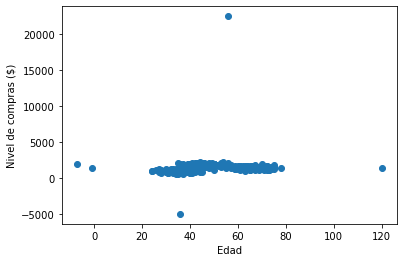

In [ ]:
# Graficar
plt.scatter(data[:,0],data[:,1])
plt.xlabel('Edad')
plt.ylabel('Nivel de compras ($)');

Vemos que no resulta fácil ver las características del set de datos pues contiene algunos *outliers* o valores atípicos:

- Algunas edades son negativas o incluso llegan a ser de 120 años
- Algunos niveles de compra son negativos o sobrepasan el nivel máximo de la mayoría de los datos

En la fase de limpieza manejaremos las inconsistencias en estos datos.

## 3 - Limpieza del set de datos

Debemos verificar dos situaciones:

- Que no haya datos incompletos y de ser así debemos determinar qué hacer con ellos
- Realizar el manejo de *outliers*

Veamos cada fase en detalle

### 3.1 - Manejo de datos incompletos

Al momento de recolectar los datos es posible que no se haya recolectado la totalidad de la información (edad, nivel de compra) para cada cliente.

En estos casos es probable que algunos elementos del set de datos no contengan cantidades numéricas y en su lugar tengan datos tipo *NaN* (*Not A Number*).

Verifiquemos esto usando herramientas de NumPy:

In [ ]:
# En primer lugar veriquemos si hay o no NaN en el dataset
np.isnan(data).any()

True

In [ ]:
# En efecto hay datos incompletos. Verifiquemos si se encuentran en la columna
# edad o en la columna nivel de compra

# Verificación de la columna edad
np.isnan(data[:,0]).any()

False

In [ ]:
# No nay datos incompletos en la columna edad. Entonces deberían estar en la columna
# nivel de compra. Verifiquemos:
np.isnan(data[:,1]).any()

True

Habiendo verificado que existen niveles de compra incompletos debemos definir la estrategia a seguir para el manejo de estos datos faltantes. En esencia existen dos alternativas:

- Eliminación del registro, que consiste en eliminar la fila completa que contenga el dato incompleto. Como resultado se tendrá un set de datos con menos registros que el set original.
- Imputación, que consiste en estimar el valor de los datos faltantes con base en datos similares. La ventaja de esta técnica es que no se deben eliminar registros.

En este caso usaremos la imputación, y en particular una técnica que se conoce como **interpolación**:

- Tomaremos la columna edad, que está completa, como la **variable independiente**. Llamémosla *x*
- Tomaremos la columna nivel de compra, incompleta, como la **variable dependiente**. Llamémosla *y*

La idea de la interpolación es obtener los valores de *y* faltantes con base en la información de los valores de *y* vecinos y de los correspondientes valores de *x*.

Por ejemplo si:
- `x = [1, 2, 3]`
- `y = [3, 2, 0]`

Y si queremos saber el valor que tendría la variable *y* en *x = 2.5*, al hacer la interpolación obtendríamos el valor *y = 1.0* que es en esencia el punto intermedio entre los dos últimos valores conocidos de *y* (2 y 0).

Esta interpolación se puede implementar de forma sencilla usando la función `interp` de NumPy:

In [ ]:
# Índices donde hay NaN y donde NO hay NaN
ind_nan = np.argwhere(np.isnan(data[:,1]))     # Estas son las posiciones a interpolar
ind_notnan = np.argwhere(~np.isnan(data[:,1]))
print(ind_nan.shape)
print(ind_notnan.shape)

(4, 1)
(369, 1)


In [ ]:
# Variables independiente (x = edad) y dependiente (y = nivel de compra) con los datos
# conocidos
x = data[ind_notnan,0]    # Vector de 369x1
x = x.flatten()           # Arreglo de 369 (requerido por la función interp)

y = data[ind_notnan,1].flatten()
print(x)

[ 38.  35.  32.  39.  38.  30.  33.  30.  43.  34.  38.  35.  30.  30.
  37.  40.  27.  31.  34.  40.  38.  39.  36.  34.  41.  36.  30.  42.
  37.  38.  44.  33.  32.  24.  36.  38.  35.  35.  39.  37.  35.  35.
  40.  35.  33.  33.  35.  36.  37.  36.  34.  28.  38.  31.  34.  41.
  36.  31.  38.  34.  33.  41.  38.  50.  30.  35.  37.  41.  34.  42.
  36.  32.  34.  35.  35.  33.  34.  40.  39.  44.  31.  30.  45.  37.
  37.  31.  37.  36.  35.  41.  32.  36.  27.  37.  30.  43.  29.  43.
  31.  28.  36.  36.  31.  29.  24.  34.  37.  26.  36.  42.  27.  38.
  38.  32.  37.  30.  37.  42.  34.  43.  41.  50.  50.  -7.  42.  51.
  48.  39.  42.  40.  37.  52.  53.  37.  49.  46.  47.  50.  50.  46.
  44.  49.  54.  40.  43.  45.  42.  44.  50.  48.  45.  46.  43.  50.
  44.  41.  44.  46.  53.  46.  44.  56.  46.  52.  48.  49.  41.  48.
  44.  41.  48.  45.  46.  50.  36.  47.  39.  38.  46.  43.  35.  45.
  46.  51.  50.  45.  39.  45.  48.  49.  50.  46.  48.  43.  44.  48.
  50. 

In [ ]:
# Los datos deben estar organizados de manera ascendente pero se debe preservar
# la relación entre las dos columnas

# Obtener los índices que organizarían "x" (edad) de manera ascendente
idx_x = np.argsort(x)
x[idx_x]

array([ -7.,  -1.,  24.,  24.,  26.,  27.,  27.,  27.,  28.,  28.,  29.,
        29.,  30.,  30.,  30.,  30.,  30.,  30.,  30.,  30.,  30.,  31.,
        31.,  31.,  31.,  31.,  31.,  31.,  32.,  32.,  32.,  32.,  32.,
        33.,  33.,  33.,  33.,  33.,  33.,  34.,  34.,  34.,  34.,  34.,
        34.,  34.,  34.,  34.,  34.,  34.,  35.,  35.,  35.,  35.,  35.,
        35.,  35.,  35.,  35.,  35.,  35.,  35.,  35.,  36.,  36.,  36.,
        36.,  36.,  36.,  36.,  36.,  36.,  36.,  36.,  36.,  36.,  37.,
        37.,  37.,  37.,  37.,  37.,  37.,  37.,  37.,  37.,  37.,  37.,
        37.,  37.,  38.,  38.,  38.,  38.,  38.,  38.,  38.,  38.,  38.,
        38.,  38.,  38.,  39.,  39.,  39.,  39.,  39.,  39.,  39.,  39.,
        40.,  40.,  40.,  40.,  40.,  40.,  41.,  41.,  41.,  41.,  41.,
        41.,  41.,  41.,  41.,  41.,  42.,  42.,  42.,  42.,  42.,  42.,
        42.,  42.,  43.,  43.,  43.,  43.,  43.,  43.,  43.,  43.,  43.,
        43.,  44.,  44.,  44.,  44.,  44.,  44.,  4

In [ ]:
# Y usar esos mismos índices para organizar y
x = x[idx_x]
y = y[idx_x]

In [ ]:
# Y ahora sí realizar la interpolación
x_interp = data[ind_nan,0].flatten() # Valores de edad donde se realizará la interpolación
y_interp = np.interp(x_interp,x,y)
print(x_interp)
print(y_interp)

[29. 37. 31. 37.]
[1024.64741674  830.31578815 1147.51441208  830.31578815]


In [ ]:
# Y reemplacemos los valores interpolados en las posiciones correspondientes del
# set de datos
data[ind_nan,1] = y_interp.reshape(4,1)

In [ ]:
# Y verifiquemos que no hay datos NaN
print(np.isnan(data[:,0]).any())
print(np.isnan(data[:,1]).any())

False
False


### 3.2 - Manejo de *outliers*

En la gráfica del set de datos vemos edades y niveles de compra por fuera de los rangos convencionales:

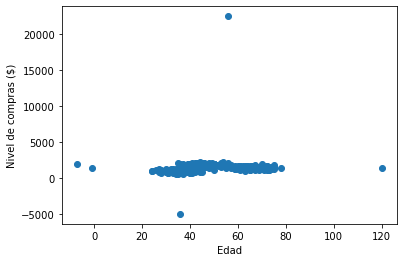

In [ ]:
plt.scatter(data[:,0],data[:,1])
plt.xlabel('Edad')
plt.ylabel('Nivel de compras ($)');

En este caso no funciona la imputación pues se trata simplemente de valores que fueron registrados incorrectamente. Así que la opción que nos queda es eliminar el registro completo (es decir las filas correspondientes):

In [ ]:
# Limpieza de edades: las filas con edades negativas o "muy grandes" serán eliminadas
mask_edad = (data[:,0] > 0) & (data[:,0] < 100)
data_c = data[mask_edad]
print(data.shape)
print(data_c.shape)

(373, 2)
(370, 2)


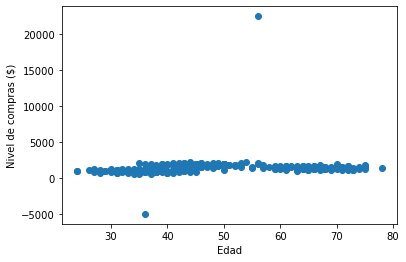

In [ ]:
plt.scatter(data_c[:,0],data_c[:,1])
plt.xlabel('Edad')
plt.ylabel('Nivel de compras ($)');

In [ ]:
# Limpieza de niveles de compra: las filas con niveles de compra negativos o superiores a 5000
# serán eliminadas
mask_compra = (data_c[:,1] > 0) & (data_c[:,1]<5000)
data_c = data_c[mask_compra]
print(data_c.shape)

(368, 2)


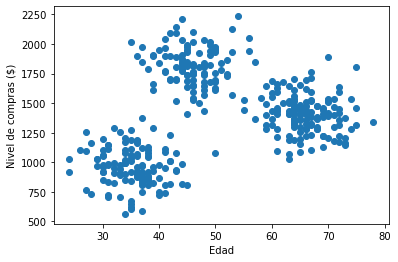

In [ ]:
plt.scatter(data_c[:,0],data_c[:,1])
plt.xlabel('Edad')
plt.ylabel('Nivel de compras ($)');

Hemos pasado de un set con 373 datos a uno con 368. Es decir que hemos eliminado 5 registros.

Veamos nuevamente nuestro dataset:

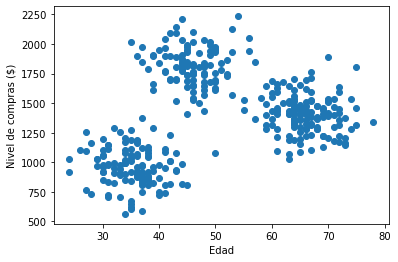

In [ ]:
# Graficar
plt.scatter(data_c[:,0],data_c[:,1])
plt.xlabel('Edad')
plt.ylabel('Nivel de compras ($)');

Al eliminar los *outliers* ya podemos ver los detalles de nuestro set de datos. Hagamos un análisis exploratorio inicial:

## 4 - Análisis exploratorio inicial

Al observar la gráfica anterior podemos ver que nuestros clientes están distribuidos en tres agrupaciones.

A partir de la gráfica podemos estimar de forma **aproximada** las características de cada segmento:

- **Segmento 1:** edades entre 20-40 y nivel de gasto entre 500 y 1500
- **Segmento 2:** edades entre 35-60 y nivel de gasto entre 1500-2250
- **Segmento 3:** edades de 60 en adelante y nivel de gasto entre 1000 y 2000

Pero por tratarse de una inspección visual, estas estimaciones son aproximadas. Necesitamos una herramienta adicional para poder determinar de forma más precisa las características de cada segmento.

## 5. Algoritmo *k-means*

Es uno de los algoritmos más sencillos, pero a la vez más usados, del *Machine Learning*. Esencialmente **permite agrupar de forma automática un set de datos, donde cada una de las *k* agrupaciones contendrá datos similares**:

![](./kmeans_idea_general.png)

La idea es usar este algoritmo para que agrupe automáticamente nuestro set de datos en *k=3* segmentos de cliente, para posteriormente caracterizar cada segmento.

Los pasos involucrados en este algoritmo son los siguientes:

### 5.1 - Escalamiento de los datos

El algoritmo se basa en el cálculo de la *distancia Euclidiana* entre pares de puntos:

![](./distancia_euclidiana.png)

Y para que ambas variables tengan el mismo peso en este cálculo se requiere que tengan la misma escala.

Como la edad y el nivel de compra están en rangos diferentes debemos hacer un escalamiento de ambas:

![](./escalamiento.png)

### 5.2 - El algoritmo en detalle

Una vez escalados los datos aplicamos estos pasos para obtener las agrupaciones:

1. Escoger *k* centroides aleatoriamente (en este caso *k=3*)
2. Definir *delta* = 200 (medirá los cambios entre los nuevos y los antiguos centroides)
3. Mientras *delta > umbral*:
    - Calcular la distancia de cada dato con respecto a cada centroide
    - Clasificar cada dato de acuerdo al centroide más cercano
    - Actualizar los centroides como el promedio de las coordenadas de los datos en cada agrupación
    - Actualizar delta: distancia promedio entre los centroides antiguos y los nuevo
    
![](./algoritmo_kmeans.png)

## 6 - Implementación del algoritmo *k-means*

Para tener un código más organizado implementaremos diferentes funciones de acuerdo al algoritmo descrito anteriormente.

Comenzaremos con la transformación de los datos:

Máximos originales: [  78.         2234.73099901]
Mínimos originales: [ 24.         562.96395647]


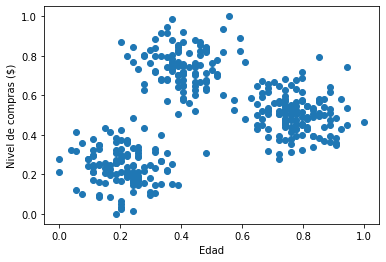

In [ ]:
def escalar_datos(datos):
    # Obtener mínimos y máximos en cada columna (edad, nivel de gasto)
    maxs = np.max(datos,axis=0)
    mins = np.min(datos,axis=0)
    
    # Escalar cada columna con base en su máximo/minimo correspondiente
    x_s = (datos[:,0]-mins[0])/(maxs[0]-mins[0]) # Escalamiento edad
    y_s = (datos[:,1]-mins[1])/(maxs[1]-mins[1]) # Escalamiento nivel de compra
    
    # Conformar el nuevo set de datos
    datos_s = np.vstack((x_s,y_s))   # Arreglo de 2 x nro_datos
    datos_s = datos_s.transpose()    # Arreglo de nro_datos x 2
    
    return maxs, mins, datos_s

# Prueba
maximos, minimos, data_s = escalar_datos(data_c)
print(f'Máximos originales: {maximos}')
print(f'Mínimos originales: {minimos}')

# Y graficar el set de datos escalado
plt.scatter(data_s[:,0],data_s[:,1])
plt.xlabel('Edad')
plt.ylabel('Nivel de compras ($)');

In [ ]:
np.random.choice(10,3, replace=False)

array([6, 5, 7])

La siguiente función permite escoger aleatoriamente *k* centroides. Para repetibilidad del algoritmo haremos uso de la semilla del generador aleatorio (`np.random.seed`):

In [ ]:
def inicializar_centroides(datos, k, seed=None):
    if seed:
        # Ajustar semilla (para reproducibilidad)
        np.random.seed(seed)
        
    # Escoger tres filas aleatoriamente
    idx = np.random.choice(datos.shape[0], k, replace=False)
    
    # Y seleccionar las coordenadas correspondientes a estas filas
    centroides = datos[idx,:]
    
    return centroides

# Prueba
centroides = inicializar_centroides(data_s, 3, 172)
print(centroides)

[[0.12962963 0.34966023]
 [0.09259259 0.24159613]
 [0.75925926 0.41197328]]


A continuación usamos NumPy para calcular la distancia entre cada punto del set de datos y cada centroide.

En este caso usaremos la función `np.linalg.norm` que permite calcular la distancia Euclidiana de manera eficiente:

In [ ]:
def calcular_distancias(datos, centroides):
    k = centroides.shape[0]    # Cantidad de centroides (k=3)
    N = datos.shape[0]         # Cantidad de datos (N=368)
    dists = np.zeros((N,k))    # N: cantidad de puntos, k: cantidad de centroides
    
    # Calcular la distancia euclidiana entre cada centroide y cada punto del dataset
    for i, centroide in enumerate(centroides):
        dists[:,i] = np.linalg.norm(datos-centroide, axis=1)
    
    return dists

# Prueba
distancias = calcular_distancias(data_s, centroides)
print(f'Tamaño del dataset: {data_s.shape}')
print(f'Tamaño del arreglo con las distancias: {distancias.shape}')
print(f'Ejemplo de una distancia (dato 5): {distancias[5]}')

Tamaño del dataset: (368, 2)
Tamaño del arreglo con las distancias: (368, 3)
Ejemplo de una distancia (dato 5): [0.10433705 0.01928519 0.66881903]


Con las distancias calculadas realizamos la clasificación de cada dato. Para ello buscamos, para cada punto, la posición correspondiente a la menor distancia calculada y la categoría será simplemente el índice en el que se encuentra dicha distancia.

Ejemplo:

- Para el dato 5 el arreglo con las distancias a los tres centroides es `[0.72, 0.08 y 0.86]`
- La menor distancia es `0.08`
- Esta menor distancia está en la posición `1`
- Así que la categoría asignada al dato 5 será precisamente la categoría `1`

Todo lo anterior lo podemos hacer usando la función argmin de NumPy:

In [ ]:
def clasificar(dists):
    cat = np.argmin(dists,axis=1)
    
    return cat

# Prueba
y = clasificar(distancias)
idx = 7
print(f'Punto a clasificar: {data_s[idx,:]}')
print(f'Centroides: \n{centroides}')
print(f'Distancias punto-centroides: {distancias[idx,:]}')
print(f'Resultado clasificación: {y[idx]}')

Punto a clasificar: [0.11111111 0.38072372]
Centroides: 
[[0.12962963 0.34966023]
 [0.09259259 0.24159613]
 [0.75925926 0.41197328]]
Distancias punto-centroides: [0.03616457 0.14035463 0.64890104]
Resultado clasificación: 0


In [ ]:
y

array([1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 2, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0,
       0, 2, 2, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 2, 0, 0,
       0, 2, 0, 0, 0, 0, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 0, 0, 2, 0, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 2, 2, 2, 0, 2, 0, 0, 2,
       2, 0, 0, 2, 0, 2, 2, 0, 0, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2,
       0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

Habiendo clasificado cada punto, el siguiente paso es actualizar los centroides.

Para ello tomamos como entrada a la función los puntos del dataset y sus respectivas categorías, y por cada categoría:
- Seleccionamos los puntos correspondientes
- Calculamos el nuevo centroide como el promedio de las coordenadas de todos los puntos
- Almacenamos el centroide obtenido

In [ ]:
def actualizar_centroides(datos, cats):
    n_cats = cats.max() + 1 # Número de categorías
    centroides = []
    
    for i in range(n_cats):
        # Tomar datos correspondientes a cada categoría
        cluster = datos[cats==i,:]
        
        # Calcular el centroide como el promedio de las coordenadas del cluster
        centroide = np.mean(cluster,axis=0)
        
        # Almacenar el centroide obtenido
        centroides.append(centroide)
        
    # Retornar los centroides en formato NumPy
    return np.asarray(centroides)

# Prueba
centroides_nuevos = actualizar_centroides(data_s, y)
print(f'Centroides iniciales: \n{centroides}')
print(f'Centroides actualizados: \n{centroides_nuevos}')
        

Centroides iniciales: 
[[0.12962963 0.34966023]
 [0.09259259 0.24159613]
 [0.75925926 0.41197328]]
Centroides actualizados: 
[[0.29343434 0.56037607]
 [0.19727366 0.17829723]
 [0.70211071 0.56640367]]


Con todas las funciones implementadas anteriormente lo único que resta es combinarlas en el algoritmo de *k-means* para de forma iterativa refinar la ubicación de los centroides:

In [ ]:
SEED = 150      # La semilla del generador aleatorio (reproducibilidad del algoritmo)
ctr_new = inicializar_centroides(data_s, 3, SEED) # Inicializar 3 centroides
delta = 200     # Puede ser cualquier valor relativamente "alto"

while delta > 1e-3:
    # Calcular distancias de cada dato con respecto a cada centroide
    dists = calcular_distancias(data_s, ctr_new)
    
    # Clasificar cada dato
    y = clasificar(dists)
    
    # Actualizar centroides
    ctr_old = ctr_new
    ctr_new = actualizar_centroides(data_s, y)
    
    # Actualizar delta
    diff = ctr_old - ctr_new
    delta = np.mean(np.linalg.norm(diff))
    print(delta)

0.33734205270636897
0.27305774805593913
0.05214199032538786
0.0


¡Y listo, ya tenemos implementado nuestro algoritmo *k-means* con pocas líneas de código!

Veamos los centroides obtenidos:

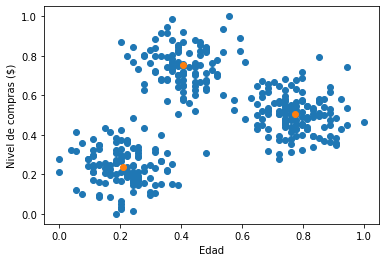

In [ ]:
plt.scatter(data_s[:,0],data_s[:,1])
plt.xlabel('Edad')
plt.ylabel('Nivel de compras ($)');

plt.scatter(ctr_new[:,0], ctr_new[:,1]);

## 7 - Análisis exploratorio detallado

Con el algoritmo de *k-means* ya hemos encontrado 3 segmentos de cliente y hemos asignado cada dato al *cluster* correspondiente. De esta forma ya podemos caracterizar cada grupo de forma detallada.

El primer paso es llevar los datos escalados a la escala original. Para ello aplicamos la transformación inversa:

$variable_{original} = [max(variable_{original})-min(variable_{original})] variable_{escalada}+min(variable_{original})$

In [ ]:
# Transformar los datos de edad (columna 0) y nivel de compra (columna 1) a la escala original
data_x = data_s[:,0]*(maximos[0]-minimos[0])+minimos[0]
data_y = data_s[:,1]*(maximos[1]-minimos[1])+minimos[1]
data_os = np.vstack((data_x,data_y)).transpose()
data_os

array([[  38.        ,  850.26639671],
       [  35.        ,  605.39376619],
       [  32.        , 1289.27733951],
       [  39.        , 1289.68286481],
       [  38.        ,  871.74374846],
       [  30.        ,  975.85653407],
       [  33.        ,  943.46575371],
       [  30.        , 1199.44532874],
       [  29.        , 1024.64741674],
       [  43.        , 1079.04695531],
       [  34.        ,  562.96395647],
       [  38.        , 1075.03641388],
       [  37.        ,  830.31578815],
       [  35.        , 1189.99385032],
       [  30.        , 1056.67857466],
       [  30.        ,  852.25621141],
       [  37.        ,  830.31578815],
       [  40.        ,  749.61668537],
       [  27.        , 1256.04000386],
       [  31.        , 1147.51441208],
       [  34.        ,  853.42080562],
       [  40.        ,  725.29447291],
       [  38.        , 1047.3061619 ],
       [  39.        ,  962.32211132],
       [  36.        ,  874.60303079],
       [  31.        , 11

Creamos los tres *clusters* con los grupos correspondientes, usando los resultados de la clasificación con *k-means* (que se encuentran en la variable `y`):

In [ ]:
# Obtener agrupaciones
cluster1 = data_os[y==0,:]
cluster2 = data_os[y==1,:]
cluster3 = data_os[y==2,:]

Y ahora sí podemos caracterizar en detalle cada segmento. Crearemos una sencilla función que nos muestre los rangos mínimo y máximo de edad y nivel de compra de cada segmento:

In [ ]:
def caracterizar_segmento(cluster, title):
    # Obtener mínimos/máximos de edad y de nivel de compra
    mins = np.min(cluster, axis=0)
    maxs = np.max(cluster, axis=0)
    
    # E imprimir información en pantalla
    print('-'*30)
    print(f'Segmento: {title}')
    print(f'\t Rango de edades: {mins[0]:.0f}-{maxs[0]:.0f} años')
    print(f'\t Niveles de compra: $ {mins[1]:.0f}-{maxs[1]:.0f}')

Y usamos la función anterior para ver los detalles de cada segmento de cliente. Adicionalmente generaremos una gráfica para entender mejor aún esta distribución:

------------------------------
Segmento: 1
	 Rango de edades: 35-57 años
	 Niveles de compra: $ 1408-2235
------------------------------
Segmento: 2
	 Rango de edades: 55-78 años
	 Niveles de compra: $ 1024-1890
------------------------------
Segmento: 3
	 Rango de edades: 24-50 años
	 Niveles de compra: $ 563-1374


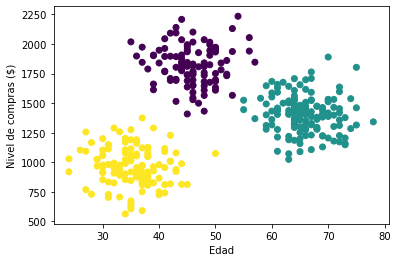

In [ ]:
# Graficar e imprimir en pantalla las características de cada cluster
caracterizar_segmento(cluster1, '1')
caracterizar_segmento(cluster2, '2')
caracterizar_segmento(cluster3, '3')

plt.scatter(data_os[:,0],data_os[:,1],c=y)
plt.xlabel('Edad')
plt.ylabel('Nivel de compras ($)');